# Ćwiczenie — przewiduj liczbę wypożyczeń rowerów (Random Forest Regressor)

Zbudujesz model regresji, który na podstawie pogody i kalendarza (dzień tygodnia,
sezon, temperatura, wilgotność...) przewiduje ile rowerów miejskich zostanie
wypożyczonych danego dnia. Dokładnie ten sam typ modelu i workflow co na zajęciach —
tylko na nowych danych.

**Dataset:** `bike_sharing.csv` — 728 dni wypożyczeń roweru miejskiego (Washington D.C.),
zero braków danych. **Plik CSV znajduje się w tym samym folderze co ten notebook —
wczytaj go stąd, a nie z internetu.**

## Setup — uruchom raz

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Wczytaj plik CSV z tego samego folderu co notebook
bike = pd.read_csv('bike_sharing.csv')
print(bike.shape)
bike.head()

(728, 18)


,instant,dteday,season,yr,mnth,holiday,weekday,temp,atemp,hum,windspeed,casual,registered,cnt,workday,weather,days_since_2011,cnt_2d_bfr
0,3,2011-01-03,WINTER,2011,JAN,N,MON,1.229108,22.439770,43.7273,16.636703,120,1229,1349,Y,GOOD,2,985
1,4,2011-01-04,WINTER,2011,JAN,N,TUE,1.400000,23.212148,59.0435,10.739832,108,1454,1562,Y,GOOD,3,801
2,5,2011-01-05,WINTER,2011,JAN,N,WED,2.666979,23.795180,43.6957,12.522300,82,1518,1600,Y,GOOD,4,1349
3,6,2011-01-06,WINTER,2011,JAN,N,THU,1.604356,23.929106,51.8261,6.000868,88,1518,1606,Y,GOOD,5,1562
4,7,2011-01-07,WINTER,2011,JAN,N,FRI,1.236534,23.100526,49.8696,11.304642,148,1362,1510,Y,MISTY,6,1600


### Kolumny datasetu

| Kolumna | Opis |
|---|---|
| `instant`, `dteday` | numer porządkowy, data — **do usunięcia** (nie są cechami predykcyjnymi) |
| `season`, `mnth`, `weekday`, `holiday`, `workday`, `weather` | cechy kategoryczne (tekstowe) |
| `yr` | rok (0 lub 1) |
| `temp`, `atemp`, `hum`, `windspeed` | cechy pogodowe (liczbowe, znormalizowane) |
| `casual`, `registered` | rozbicie `cnt` na dwie grupy — **do usunięcia** (używanie ich byłoby data leakage, bo razem dają dokładnie `cnt`!) |
| `cnt_2d_bfr` | liczba wypożyczeń 2 dni wcześniej — **do usunięcia** dla uproszczenia |
| `cnt` | **cel predykcji** — łączna liczba wypożyczeń danego dnia |

---
### ✏️ Zadanie 1 — Usuń zbędne i "podpowiadające" kolumny

Usuń kolumny, które nie powinny brać udziału w treningu: `instant`, `dteday`,
`casual`, `registered`, `cnt_2d_bfr`.

**Wskazówki:**
- `bike.drop(columns=[...])`
- Zapisz wynik do nowej zmiennej, np. `bike_clean`

**⚠️ Dlaczego usuwamy `casual` i `registered`?**
Bo `casual + registered = cnt` dokładnie! Gdyby model je widział, "oszukiwałby"
zamiast się uczyć — to klasyczny przykład data leakage.

In [53]:
# Napisz tutaj swój kod
bike_clean = bike.copy()
bike_clean.drop(columns=['instant', 'dteday', 'casual', 'registered', 'cnt_2d_bfr'], inplace=True)


---
### ✏️ Zadanie 2 — Zamień kolumny kategoryczne na liczbowe

Kolumny `season`, `mnth`, `holiday`, `weekday`, `workday`, `weather` są tekstowe.
Zamień je na kolumny 0/1 funkcją `pd.get_dummies()`.

**Wskazówki:**
- `pd.get_dummies(bike_clean, columns=[...], drop_first=True)`

In [54]:
# Napisz tutaj swój kod
bike_clean = pd.get_dummies(bike_clean, columns=['season', 'mnth', 'holiday', 'weekday', 'workday', 'weather'],drop_first=True)


---
### ✏️ Zadanie 3 — Podział danych i standaryzacja

Podziel dane na X (cechy) i y (`cnt`), potem na train/test (80/20). Zestandaryzuj cechy.

**Wskazówki:**
- `X = df.drop('cnt', axis=1)`, `y = df['cnt']`
- `train_test_split(X, y, test_size=0.2, random_state=42)`
- `StandardScaler()` — `fit_transform` na train, `transform` na test!

In [55]:
# Napisz tutaj swój kod
y, X = bike_clean['cnt'], bike_clean.drop('cnt', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


---
### ✏️ Zadanie 4 — Trening i ewaluacja modelu

Wytrenuj `RandomForestRegressor` (200 drzew) i oceń go na zbiorze testowym:
R² oraz MAE (średni błąd w liczbie rowerów).

**Wskazówki:**
- `RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)`
- `r2_score(y_test, y_pred)`, `mean_absolute_error(y_test, y_pred)`

In [56]:
# Napisz tutaj swój kod

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

r2 = r2_score(y_test, rf.predict(X_test_scaled))
mae = mean_absolute_error(y_test, rf.predict(X_test_scaled))

print(f'R^2: {r2}')
print(f'MAE: {mae}')

R^2: 0.8520975215385407
MAE: 467.63554794520553


---
### ✏️ Zadanie 5 (bonus) — Które cechy najbardziej wpływają na liczbę wypożyczeń?

Zwizualizuj `feature_importances_` modelu jako poziomy wykres słupkowy
(pokaż tylko 10 najważniejszych cech).

**Wskazówki:**
- `model.feature_importances_`
- `pd.Series(importances, index=X.columns).sort_values().tail(10).plot(kind='barh')`

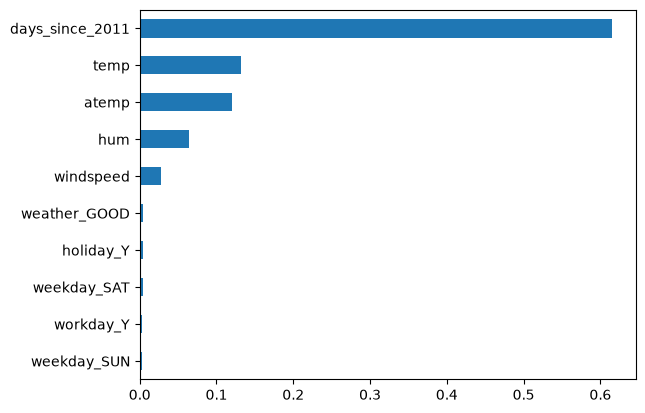

In [57]:
# Napisz tutaj swój kod

feature_importances = rf.feature_importances_
importances = pd.Series(feature_importances, index=X.columns).sort_values().tail(10).plot(kind='barh')
